# PCL Coursework Runner

This notebook is the main interactive runner for the coursework.

It is organized around the coursework flow:
- run tests
- Part 2: data loading and EDA
- Part 3: inspect model configuration
- Part 4: train, evaluate, and export predictions

This notebook is the primary execution surface for guided runs, visual inspection, and report preparation. The command-line interface remains available as a lower-level utility layer.

For the plotting cells to render and save figures, install the project dependencies from `requirements.txt`, which now include `matplotlib`.

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path
from pprint import pprint


def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "src").is_dir() and (candidate / "configs").is_dir():
            return candidate
    raise RuntimeError("Could not find the repository root.")


ROOT = find_repo_root(Path.cwd())
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from pcl_detection.notebook_support import (
    build_notebook_context,
    export_default_submission_files,
    load_training_artifacts,
    run_unittest_targets,
)

context = build_notebook_context(ROOT)
best_config_path = context.best_config_path

print(f"Repository root: {ROOT}")
print(f"Python executable: {sys.executable}")
print(f"Default config: {best_config_path.name}")


Repository root: C:\Users\16579\Documents\PyCharmProjects\pcl-detection-nlp
Python executable: C:\Users\16579\Documents\PyCharmProjects\pcl-detection-nlp\.venv\Scripts\python.exe
Default config: best_hybrid_ensemble.json


## Run Tests

Run these first. They verify that the project still works before you inspect data or retrain the model.

In [2]:
run_unittest_targets()
run_unittest_targets("tests.test_data")
run_unittest_targets("tests.test_metrics")
run_unittest_targets("tests.test_export")

test_binary_label_conversion (test_data.DataLoadingTests.test_binary_label_conversion) ... ok
test_load_dataset_bundle (test_data.DataLoadingTests.test_load_dataset_bundle) ... ok
test_rank_experiments_returns_sorted_rows (test_experiments.ExperimentSummaryTests.test_rank_experiments_returns_sorted_rows) ... ok
test_existing_submission_files_match_spec_format (test_export.ExportTests.test_existing_submission_files_match_spec_format) ... ok
test_validate_submission_predictions_rejects_count_mismatch (test_export.ExportTests.test_validate_submission_predictions_rejects_count_mismatch) ... ok
test_validate_submission_predictions_rejects_non_binary_labels (test_export.ExportTests.test_validate_submission_predictions_rejects_non_binary_labels) ... ok
test_compute_binary_metrics (test_metrics.MetricsTests.test_compute_binary_metrics) ... ok

----------------------------------------------------------------------
Ran 7 tests in 0.675s

OK
test_binary_label_conversion (tests.test_data.DataLoadi

<unittest.runner.TextTestResult run=3 errors=0 failures=0>

## Part 2: Data Loading And EDA

This section loads the SemEval PCL splits, prints basic dataset sizes, generates the EDA artifact, and visualizes a few simple summaries.

In [3]:
from pcl_detection.data_pipeline import build_eda_report, load_dataset_bundle, run_stats

bundle = load_dataset_bundle(ROOT / "data")
print("Split sizes:")
print({"train": len(bundle.train), "dev": len(bundle.dev), "test": len(bundle.test)})

eda_report = build_eda_report(bundle)
print("Train split summary:")
pprint(eda_report["train"])
print("Dev split summary:")
pprint(eda_report["dev"])
print("Top positive keywords:")
pprint(eda_report["top_positive_keywords"][:10])

run_stats(best_config_path)

Split sizes:
{'train': 8375, 'dev': 2094, 'test': 3832}
Train split summary:
{'avg_tokens': 48.68,
 'binary_label_distribution': {0: 7581, 1: 794},
 'max_tokens': 909,
 'min_tokens': 1,
 'size': 8375}
Dev split summary:
{'avg_tokens': 47.41,
 'binary_label_distribution': {0: 1895, 1: 199},
 'max_tokens': 272,
 'min_tokens': 0,
 'size': 2094}
Top positive keywords:
[('homeless', 149),
 ('in-need', 143),
 ('poor-families', 112),
 ('hopeless', 98),
 ('refugee', 73),
 ('disabled', 67),
 ('vulnerable', 60),
 ('women', 38),
 ('migrant', 31),
 ('immigrant', 23)]


{'train': {'size': 8375,
  'binary_label_distribution': {1: 794, 0: 7581},
  'avg_tokens': 48.68,
  'min_tokens': 1,
  'max_tokens': 909},
 'dev': {'size': 2094,
  'binary_label_distribution': {1: 199, 0: 1895},
  'avg_tokens': 47.41,
  'min_tokens': 0,
  'max_tokens': 272},
 'test': {'size': 3832,
  'binary_label_distribution': {},
  'avg_tokens': 48.36,
  'min_tokens': 4,
  'max_tokens': 379},
 'top_train_keywords': [('migrant', 882),
  ('refugee', 880),
  ('vulnerable', 871),
  ('homeless', 865),
  ('in-need', 856),
  ('immigrant', 843),
  ('women', 837),
  ('disabled', 834),
  ('hopeless', 788),
  ('poor-families', 719)],
 'top_positive_keywords': [('homeless', 149),
  ('in-need', 143),
  ('poor-families', 112),
  ('hopeless', 98),
  ('refugee', 73),
  ('disabled', 67),
  ('vulnerable', 60),
  ('women', 38),
  ('migrant', 31),
  ('immigrant', 23)]}

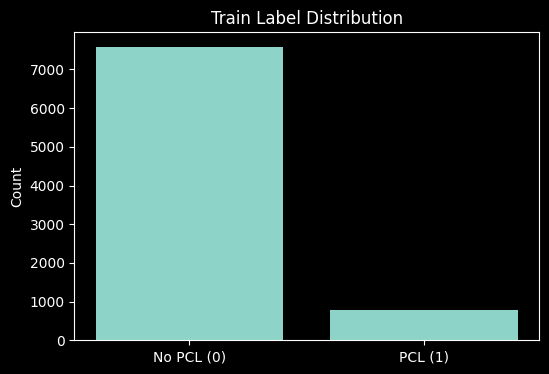

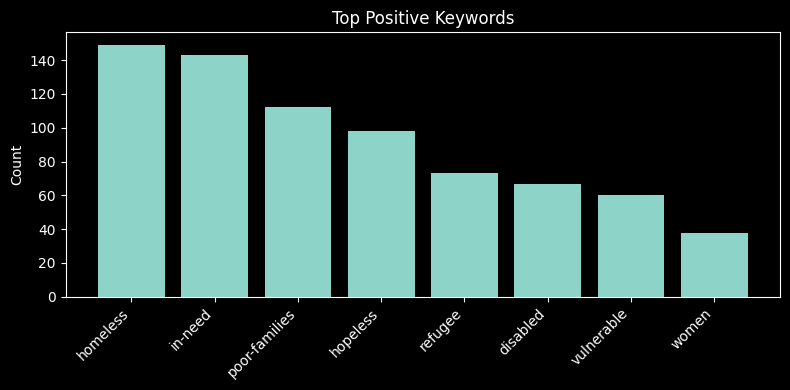

In [4]:
try:
    import matplotlib.pyplot as plt
except ImportError as exc:
    raise RuntimeError("matplotlib is required in the notebook for plots.") from exc

train_distribution = eda_report["train"]["binary_label_distribution"]
labels = ["No PCL (0)", "PCL (1)"]
values = [train_distribution.get(0, 0), train_distribution.get(1, 0)]

plt.figure(figsize=(6, 4))
plt.bar(labels, values)
plt.title("Train Label Distribution")
plt.ylabel("Count")
plt.show()

keywords = [item[0] for item in eda_report["top_positive_keywords"][:8]]
counts = [item[1] for item in eda_report["top_positive_keywords"][:8]]

plt.figure(figsize=(8, 4))
plt.bar(keywords, counts)
plt.title("Top Positive Keywords")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Part 3: Model Configuration

This section inspects the current recommended TF-IDF + SVM setup before running training.

In [5]:
best_config = json.loads(best_config_path.read_text(encoding="utf-8"))
print(f"Loaded config: {best_config_path.name}")
pprint(best_config)

print("\nKey modeling choices:")
model_name = best_config["model_name"]
print("- model:", model_name)

if model_name == "tfidf_svm":
    tfidf_cfg = best_config["tfidf"]
    svm_cfg = best_config["svm"]
    print("- word ngrams:", (tfidf_cfg["ngram_min"], tfidf_cfg["ngram_max"]))
    print("- char ngrams:", (tfidf_cfg["char_ngram_min"], tfidf_cfg["char_ngram_max"]))
    print("- sublinear tf:", tfidf_cfg.get("sublinear_tf"))
    print("- stop words:", tfidf_cfg.get("stop_words"))
    print("- svm C:", svm_cfg["c"])
elif model_name == "tfidf_ensemble":
    ensemble_cfg = best_config["ensemble"]
    print("- ensemble threshold:", ensemble_cfg.get("threshold"))
    print("- ensemble weights:", ensemble_cfg.get("weights"))
    print("- member count:", len(ensemble_cfg.get("members", [])))
    for index, member in enumerate(ensemble_cfg.get("members", []), start=1):
        print(f"  member {index}: {member['kind']}")
        member_tfidf = member.get("tfidf", {})
        if member_tfidf:
            print("    word ngrams:", (member_tfidf.get("ngram_min"), member_tfidf.get("ngram_max")))
            print("    char ngrams:", (member_tfidf.get("char_ngram_min"), member_tfidf.get("char_ngram_max")))
        member_svm = member.get("svm", {})
        if member_svm:
            print("    classifier C:", member_svm.get("c"))
        member_latent = member.get("latent", {})
        if member_latent:
            print("    latent components:", member_latent.get("n_components"))
else:
    roberta_cfg = best_config["roberta"]
    print("- backbone:", roberta_cfg.get("pretrained_model_name"))
    print("- max length:", roberta_cfg.get("max_length"))
    print("- learning rate:", roberta_cfg.get("learning_rate"))
    print("- epochs:", roberta_cfg.get("epochs"))

Loaded config: best_hybrid_ensemble.json
{'artifacts_dir': 'artifacts/best_hybrid_ensemble',
 'data_dir': 'data',
 'ensemble': {'members': [{'kind': 'tfidf_svm',
                           'svm': {'c': 0.18,
                                   'class_weight': 'balanced',
                                   'classifier_type': 'linear_svc'},
                           'tfidf': {'char_max_features': 50000,
                                     'char_ngram_max': 5,
                                     'char_ngram_min': 3,
                                     'max_features': 30000,
                                     'min_df': 1,
                                     'ngram_max': 2,
                                     'ngram_min': 1,
                                     'stop_words': None,
                                     'sublinear_tf': True}},
                          {'kind': 'tfidf_svm',
                           'svm': {'c': 0.22,
                                   'class_weight': 

## Part 4: Train, Evaluate, And Export

This section trains the recommended configuration, shows the dev metrics and error examples, and exports `dev.txt` / `test.txt` in the coursework submission format.

In [6]:
from pcl_detection.training_pipeline import train_from_config

train_result = train_from_config(best_config_path)
pprint(train_result)

{'artifacts_dir': 'artifacts\\best_hybrid_ensemble',
 'error_count': 25,
 'metrics': {'f1': 0.4655172413793104,
             'fn': 91,
             'fp': 157,
             'precision': 0.4075471698113208,
             'recall': 0.542713567839196,
             'tn': 1738,
             'tp': 108},
 'model_name': 'tfidf_ensemble'}


In [7]:
artifact_bundle = load_training_artifacts(ROOT / best_config["artifacts_dir"])
metrics = artifact_bundle["metrics"]
errors = artifact_bundle["errors"]

print("Metrics:")
pprint(metrics)

print("\nFirst 3 error examples:")
pprint(errors[:3])

Metrics:
{'f1': 0.4655172413793104,
 'fn': 91,
 'fp': 157,
 'precision': 0.4075471698113208,
 'recall': 0.542713567839196,
 'tn': 1738,
 'tp': 108}

First 3 error examples:
[{'gold': 1,
  'keyword': 'refugee',
  'pred': 0,
  'record_id': '8330',
  'text': "Many refugees do n't want to be resettled anywhere , let alone in "
          'the US .'},
 {'gold': 1,
  'keyword': 'homeless',
  'pred': 0,
  'record_id': '4089',
  'text': '"In a 90-degree view of his constituency , one can see a high rise '
          'and a flyover while underneath it , homeless people sleep on '
          'pavements . "" As you can see , my constituency is not confined to '
          'one socio-economic group , "" he said , adding that apart from '
          'water , another major concern for him is to improve the standard of '
          'public schools in the area ."'},
 {'gold': 1,
  'keyword': 'poor-families',
  'pred': 0,
  'record_id': '2001',
  'text': 't is remiss not to mention here that not all scavengi

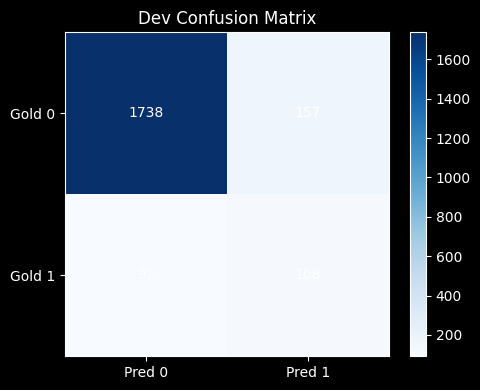

In [8]:
tp = metrics["tp"]
fp = metrics["fp"]
fn = metrics["fn"]
tn = metrics["tn"]

matrix = [[tn, fp], [fn, tp]]

plt.figure(figsize=(5, 4))
plt.imshow(matrix, cmap="Blues")
plt.title("Dev Confusion Matrix")
plt.xticks([0, 1], ["Pred 0", "Pred 1"])
plt.yticks([0, 1], ["Gold 0", "Gold 1"])

for row_index, row in enumerate(matrix):
    for col_index, value in enumerate(row):
        plt.text(col_index, row_index, str(value), ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.show()

In [9]:
pprint(export_default_submission_files(best_config_path, ROOT))

{'dev_line_count': 2094,
 'dev_path': 'C:\\Users\\16579\\Documents\\PyCharmProjects\\pcl-detection-nlp\\dev.txt',
 'dev_preview': ['1', '1', '0', '1', '0'],
 'test_line_count': 3832,
 'test_path': 'C:\\Users\\16579\\Documents\\PyCharmProjects\\pcl-detection-nlp\\test.txt',
 'test_preview': ['0', '1', '0', '0', '0']}


## Notes

- Use this notebook for guided runs and plots.
- Use the command-line interface only when you need lower-level batch-style runs.
- If you create new configs, update the selected config path in the setup cell and rerun the training/export blocks.